In [1]:
#Research Question: For a restaurant chain using Yelp reviews as a voice-of-customer channel, can a neural NLP model accurately classify sentence-level sentiment?

In [2]:
import pandas as pd
import numpy as np

In [3]:
#Loading file
path = "C:\\Users\\weepo\\Documents\\WGU\\D213\\Task 2\\sentiment labelled sentences\\yelp_labelled.txt"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split("\t")
        text = "\t".join(parts[:-1]) if len(parts) > 2 else parts[0]
        label = int(parts[-1])
        rows.append((text, label))

df = pd.DataFrame(rows, columns=["text", "label"])

#Checking if it's all good
print(df.shape)
print(df["label"].value_counts())
df.head()

(1000, 2)
label
1    500
0    500
Name: count, dtype: int64


,text,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [4]:
#Checking for unusual characters first
import re
import string

#Non-ASCII detection
def has_non_ascii(s: str) -> bool:
    return any(ord(ch) > 127 for ch in s)

non_ascii_mask = df["text"].apply(has_non_ascii)
print("Non-ASCII rows:", non_ascii_mask.sum())
print(df.loc[non_ascii_mask, "text"].head(10).to_list())

#Emoji detection
emoji_ranges = [
    (0x1F300, 0x1F5FF), (0x1F600, 0x1F64F), (0x1F680, 0x1F6FF),
    (0x1F900, 0x1F9FF), (0x1FA00, 0x1FAFF), (0x2600, 0x26FF), (0x2700, 0x27BF)
]
def contains_emoji(s: str) -> bool:
    for ch in s:
        o = ord(ch)
        if any(a <= o <= b for a, b in emoji_ranges):
            return True
    return False

emoji_mask = df["text"].apply(contains_emoji)
print("Emoji rows:", emoji_mask.sum())
print(df.loc[emoji_mask, "text"].head(10).to_list())

#Other unusuall characters
common = set(string.ascii_letters + string.digits + string.punctuation + " \t\n\r")
def unusual_chars(s: str):
    return sorted(set(ch for ch in s if ch not in common))

unusual = df["text"].apply(unusual_chars)
unusual_mask = unusual.apply(lambda xs: len(xs) > 0)

#Printing the culprits
print("Rows with unusual chars:", unusual_mask.sum())
print(unusual[unusual_mask].head(10).to_list())
print(df.loc[unusual_mask, "text"].head(10).to_list())


Non-ASCII rows: 4
['My fiancé and I came in the middle of the day and we were greeted and seated right away.', 'I really enjoyed Crema Café before they expanded; I even told friends they had the BEST breakfast.', 'The crêpe was delicate and thin and moist.', "The only thing I wasn't too crazy about was their guacamole as I don't like it puréed."]
Emoji rows: 0
[]
Rows with unusual chars: 4
[['é'], ['é'], ['ê'], ['é']]
['My fiancé and I came in the middle of the day and we were greeted and seated right away.', 'I really enjoyed Crema Café before they expanded; I even told friends they had the BEST breakfast.', 'The crêpe was delicate and thin and moist.', "The only thing I wasn't too crazy about was their guacamole as I don't like it puréed."]


In [5]:
#Vocabulary size
import re

token_pattern = re.compile(r"[A-Za-zÀ-ÿ']+")  # keeps contractions + accented latin chars

tokens = df["text"].str.lower().apply(lambda s: token_pattern.findall(s))

vocab = set()
for toks in tokens:
    vocab.update(toks)

print("Vocabulary size (word-level):", len(vocab))
print("Sample vocab:", sorted(list(vocab))[:30])

Vocabulary size (word-level): 2042
Sample vocab: ['a', 'about', 'above', 'absolute', 'absolutely', 'absolutley', 'accident', 'accommodations', 'accomodate', 'accordingly', 'accountant', 'ache', 'acknowledged', 'across', 'actual', 'actually', 'added', 'affordable', 'after', 'afternoon', 'again', 'ago', 'ahead', 'airline', 'airport', 'ala', 'albondigas', 'all', 'allergy', 'almonds']


In [6]:
#Computing token length distribution and percentiles

seq_lens = tokens.apply(len)

print(seq_lens.describe())
for p in [90, 95, 97.5, 99, 100]:
    print(f"p{p}: {np.percentile(seq_lens, p)}")

def coverage(L):
    return (seq_lens <= L).mean()

for L in [16, 20, 23, 25, 28, int(seq_lens.max())]:
    print(f"Max_len={L:>2} covers {coverage(L)*100:.1f}% of sentences")


count    1000.000000
mean       10.830000
std         6.213832
min         1.000000
25%         6.000000
50%        10.000000
75%        15.000000
max        32.000000
Name: text, dtype: float64
p90: 20.0
p95: 23.0
p97.5: 25.0
p99: 28.0
p100: 32.0
Max_len=16 covers 80.7% of sentences
Max_len=20 covers 90.4% of sentences
Max_len=23 covers 96.0% of sentences
Max_len=25 covers 97.8% of sentences
Max_len=28 covers 99.4% of sentences
Max_len=32 covers 100.0% of sentences


In [7]:
#Tokenization
import tensorflow as tf
df.head(), df["label"].value_counts()

(                                                text  label
 0                           Wow... Loved this place.      1
 1                                 Crust is not good.      0
 2          Not tasty and the texture was just nasty.      0
 3  Stopped by during the late May bank holiday of...      1
 4  The selection on the menu was great and so wer...      1,
 label
 1    500
 0    500
 Name: count, dtype: int64)

In [8]:
from sklearn.model_selection import train_test_split

X = df["text"].astype(str).values
y = df["label"].values

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


700 150 150


In [9]:
MAX_LEN = 25
MAX_TOKENS = 5000

def custom_standardize(text):
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, r"<br\s*/?>", " ")
    text = tf.strings.regex_replace(text, r"[^a-z0-9'\s]+", " ")
    text = tf.strings.regex_replace(text, r"\s+", " ")
    return tf.strings.strip(text)

vectorizer = tf.keras.layers.TextVectorization(
    standardize=custom_standardize,
    split="whitespace",
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

In [10]:
vectorizer.adapt(X_train.astype(str).to_numpy())

vocab = vectorizer.get_vocabulary()
print("Vocabulary size:", len(vocab))
print("First 20 tokens:", vocab[:20])


Vocabulary size: 1673
First 20 tokens: ['', '[UNK]', 'the', 'and', 'i', 'was', 'a', 'to', 'is', 'this', 'it', 'of', 'food', 'not', 'in', 'place', 'for', 'good', 'service', 'my']


In [11]:
sample = tf.constant(["The food isn't good, not coming back."])

print("Standardized:")
print(custom_standardize(sample).numpy()[0].decode())

print("Token IDs:")
print(vectorizer(sample).numpy())

Standardized:
the food isn't good not coming back
Token IDs:
[[  2  12 393  17  13 145  30   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]]


In [12]:
BATCH_SIZE = 32

def make_dataset(texts, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(len(texts), seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val, y_val)
test_ds  = make_dataset(X_test, y_test)

In [13]:
for batch_text, batch_labels in train_ds.take(1):
    print("Batch text shape:", batch_text.shape)
    print("Batch labels shape:", batch_labels.shape)

Batch text shape: (32,)
Batch labels shape: (32,)


In [14]:
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Embedding(input_dim=len(vocab), output_dim=64),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [15]:
#Vectorize the splits for use with model.fit
X_train_vec = vectorizer(tf.constant(X_train)).numpy()
X_val_vec   = vectorizer(tf.constant(X_val)).numpy()
X_test_vec  = vectorizer(tf.constant(X_test)).numpy()

In [16]:
#Saving dataset
train_df = pd.DataFrame(X_train_vec)
train_df.insert(0, "label", y_train)
train_df.to_csv(r"C:\Users\weepo\Documents\WGU\D213\Task 2\prepared_train.csv", index=False)

print("Training set saved to prepared_train.csv")
print(f"Shape: {train_df.shape}")
train_df.head()

Training set saved to prepared_train.csv
Shape: (700, 26)


,label,0,1,2,3,4,5,6,7,8,...,15,16,17,18,19,20,21,22,23,24
0,1,4,52,160,137,2,449,51,98,51,...,0,0,0,0,0,0,0,0,0,0
1,0,140,4,256,205,1636,3,4,130,19,...,0,0,0,0,0,0,0,0,0,0
2,1,2,100,27,23,2,212,8,23,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1412,38,33,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,4,146,677,28,31,28,63,25,78,...,0,0,0,0,0,0,0,0,0,0


In [17]:
#Reset tmodel to start fresh
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Embedding(input_dim=len(vocab), output_dim=64),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [18]:
#Early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50

22/22 [==============================] - 1s 9ms/step - loss: 0.6929 - accuracy: 0.5286 - val_loss: 0.6905 - val_accuracy: 0.5267
Epoch 2/50
22/22 [==============================] - 0s 3ms/step - loss: 0.6857 - accuracy: 0.5971 - val_loss: 0.6852 - val_accuracy: 0.6333
Epoch 3/50
22/22 [==============================] - 0s 3ms/step - loss: 0.6693 - accuracy: 0.7857 - val_loss: 0.6721 - val_accuracy: 0.6733
Epoch 4/50
22/22 [==============================] - 0s 3ms/step - loss: 0.6297 - accuracy: 0.8243 - val_loss: 0.6485 - val_accuracy: 0.7267
Epoch 5/50
22/22 [==============================] - 0s 3ms/step - loss: 0.5584 - accuracy: 0.8743 - val_loss: 0.6070 - val_accuracy: 0.7000
Epoch 6/50
22/22 [==============================] - 0s 3ms/step - loss: 0.4535 - accuracy: 0.9086 - val_loss: 0.5615 - val_accuracy: 0.7200
Epoch 7/50
22/22 [==============================] - 0s 3ms/step - loss: 0.3491 - accuracy: 0.9286 - val_loss: 0.5247 - val_accuracy: 0.7400
Epoch 8/50
22/22 [=

In [19]:
#Model evaluation
#Evaluate on test set
loss, acc = model.evaluate(X_test_vec, y_test)
print(f"Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

5/5 [==============================] - 0s 1ms/step - loss: 0.3749 - accuracy: 0.8333
Test Loss: 0.3749 | Test Accuracy: 0.8333


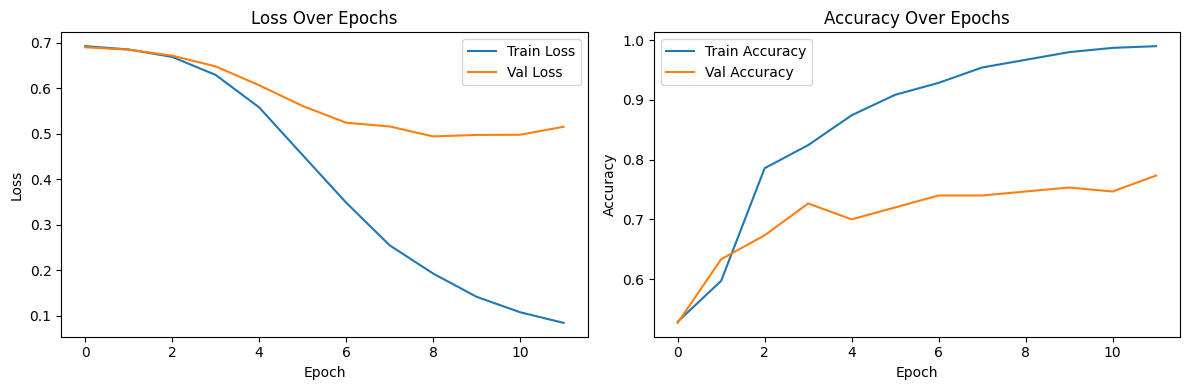

In [20]:
#Training visualizations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [21]:
model.save("sentiment_model.keras")
print("Model saved.")

Model saved.


In [22]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, None, 64)          107072    
                                                                 
 global_average_pooling1d_1  (None, 64)                0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 111297 (434.75 KB)
Trainable params: 111297 (434.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
